In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [1]:
IMAGE_SIZE=256
BATCH_SIZE=32

CHANNEL=102
EPOCHS=30

loading the data and processing

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory("villageplants",
                                                   shuffle=True,image_size=(IMAGE_SIZE,IMAGE_SIZE),
                                                    batch_size=BATCH_SIZE
                                                   )

Found 2152 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names

In [5]:
len(dataset)


68

to acces the image from the dataset

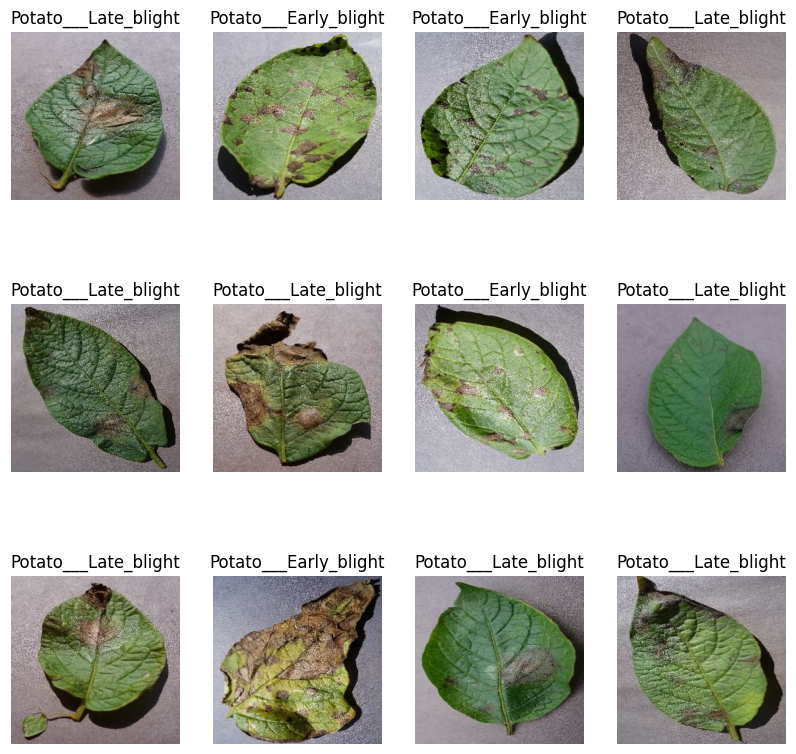

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

    
    

In [8]:
80%==>training
20%==>10% validation,10%test

SyntaxError: invalid syntax (1968740877.py, line 1)

In [9]:
train_size=0.8
len(dataset)*train_size

54.400000000000006

In [10]:
train_ds=dataset.take(54)

In [11]:
test_ds=dataset.skip(54)


14

In [12]:
val_ds=test_ds*0.1

6.800000000000001

In [13]:
val_ds=test_ds.take(6)

In [14]:
test_ds=test_ds.skip(6)
len(test_ds)

8

for training run fast

In [15]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

scaling 

In [16]:
resize_and_rescale=tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2), 
])

In [1]:
n_class=3
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNEL)
model=models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu',),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_class,activation='softmax'),])
model.build(input_shape=input_shape)


NameError: name 'IMAGE_SIZE' is not defined

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [21]:
history=model.fit(
    train_ds,
    epochs=60,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4688 - loss: 0.9444 - val_accuracy: 0.5046 - val_loss: 0.8445
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6195 - loss: 0.7749 - val_accuracy: 0.7425 - val_loss: 0.6065
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7729 - loss: 0.5199 - val_accuracy: 0.8733 - val_loss: 0.3485
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8675 - loss: 0.3600 - val_accuracy: 0.8628 - val_loss: 0.3515
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8811 - loss: 0.2711 - val_accuracy: 0.8958 - val_loss: 0.2547
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9052 - loss: 0.2236 - val_accuracy: 0.8912 - val_loss: 0.2492
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9312 - loss: 0.1953 - val_accuracy: 0.9253 - val_loss: 0.1910
Epoch 8/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8945 - loss: 0.2629 - val_accuracy: 0.8889 - val_loss:

In [60]:
import os

# Set the model version
model_version = 4

# Define the directory path
model_dir = "../models"

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save the model with the .keras extension
model.save(f"{model_dir}/{model_version}.keras")



first image to predict
acctual label: Potato___Late_blight
tf.Tensor(
[[[[151. 149. 163.]
   [158. 156. 170.]
   [160. 158. 172.]
   ...
   [164. 162. 176.]
   [161. 159. 173.]
   [155. 153. 167.]]

  [[150. 148. 162.]
   [156. 154. 168.]
   [158. 156. 170.]
   ...
   [154. 152. 166.]
   [154. 152. 166.]
   [153. 151. 165.]]

  [[149. 147. 161.]
   [153. 151. 165.]
   [154. 152. 166.]
   ...
   [146. 144. 158.]
   [149. 147. 161.]
   [154. 152. 166.]]

  ...

  [[100.  94. 106.]
   [105.  99. 111.]
   [105.  99. 111.]
   ...
   [105.  99. 109.]
   [ 98.  92. 102.]
   [ 95.  89.  99.]]

  [[ 95.  89. 101.]
   [103.  97. 109.]
   [104.  98. 110.]
   ...
   [ 95.  89.  99.]
   [105.  99. 109.]
   [112. 106. 116.]]

  [[ 89.  83.  95.]
   [ 99.  93. 105.]
   [102.  96. 108.]
   ...
   [108. 102. 112.]
   [118. 112. 122.]
   [113. 107. 117.]]]


 [[[154. 156. 177.]
   [144. 146. 167.]
   [138. 140. 161.]
   ...
   [102. 105. 122.]
   [ 92.  95. 112.]
   [ 97. 100. 117.]]

  [[178. 180. 201.

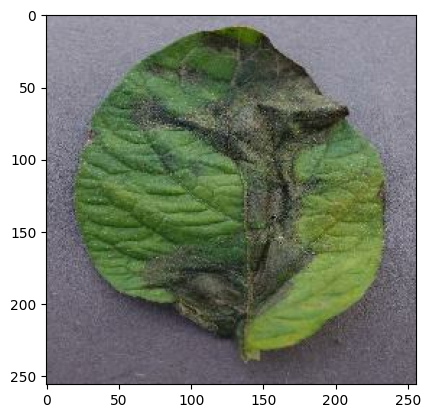

In [66]:
for image_batch,labels_batch in test_ds.take(1):
    first_image=image_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("acctual label:",class_names[first_label])
    print(first)
    batch_prediction=model.predict(image_batch)
    print(batch_prediction[0])

In [59]:
import numpy
a=[1.0000000e+00 ,2.8717892e-08 ,3.5580539e-17]
b=numpy.argmax(a)
print(b)

0


In [41]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [1]:
# Assuming `model` is your trained model
model.save(r'C:\Users\AKHIL\tomatomodel\models\model1.keras')


NameError: name 'model' is not defined

In [ ]:
model1 = tf.keras.models.load_model(r'C:\Users\AKHIL\OneDrive\Desktop\amodel/my_model.keras')
model1.predict()